# Instituto Federal da Paraíba - IFPB
**Disciplina:** Processamento Digital de Sinais (PDS)  
**Aluno:** Keviny Ryan Dantas  
**Atividade:** Estudo Dirigido 3 - Análise no Domínio da Frequência

---

## Questão 1: Espectro de uma Senoide Simples

**Objetivo:** Gerar uma senoide discreta de frequência normalizada $f_0 = 0,1$ e comprimento $N = 128$. Representar o sinal no domínio do tempo e calcular seu espectro utilizando a FFT, identificando no gráfico a frequência dominante observada.

In [1]:
!apt-get update > /dev/null
!apt install octave > /dev/null
!pip install oct2py > /dev/null
%load_ext oct2py.ipython

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


Extracting templates from packages: 100%
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipykernel==6.17.1, but you have ipykernel 7.2.0 which is incompatible.
google-colab 1.0.0 requires tornado==6.5.1, but you have tornado 6.5.5 which is incompatible.
notebook 6.5.7 requires jupyter-client<8,>=5.3.4, but you have jupyter-client 8.8.0 which is incompatible.
jupyter-kernel-gateway 2.5.2 requires jupyter-client<8.0,>=5.2.0, but you have jupyter-client 8.8.0 which is incompatible.


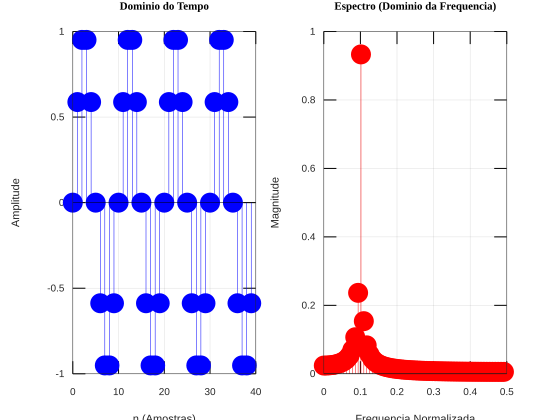

In [3]:
%%octave
clc; clear; close all;

% Parametros do sinal
N = 128;               % Numero de amostras
n = 0:N-1;             % Vetor de tempo discreto
f0 = 0.1;              % Frequencia normalizada

% Geracao do sinal
x1 = sin(2*pi*f0*n);

% Calculo da FFT
X1 = fft(x1);
X1_mag = abs(X1) / (N/2); % Magnitude normalizada
f_eixo = (0:N-1)/N;       % Eixo de frequencias normalizadas (0 a 1)

% Plotagem
figure;

subplot(1, 2, 1);
stem(n(1:40), x1(1:40), 'filled', 'b');
grid on; title('Dominio do Tempo'); xlabel('n (Amostras)'); ylabel('Amplitude');

subplot(1, 2, 2);
stem(f_eixo(1:N/2), X1_mag(1:N/2), 'filled', 'r');
grid on; title('Espectro (Dominio da Frequencia)'); xlabel('Frequencia Normalizada'); ylabel('Magnitude');

**Discussão (Questão 1):** No domínio do tempo, visualizamos o comportamento oscilatório padrão da senoide ao longo das amostras. Ao transitar para o domínio da frequência via FFT, o gráfico sintetiza a informação exibindo um pico perfeitamente nítido e isolado em $f = 0,1$. Isso confirma numericamente e graficamente a frequência dominante configurada na geração do sinal.

## Questão 2: Separação de Frequências Distintas

**Objetivo:** Gerar duas senoides de frequências distintas e somar os sinais obtidos. Em seguida, calcular a FFT do sinal resultante e verificar se o espectro permite distinguir corretamente as duas componentes em frequência, discutindo a relação entre o domínio do tempo e o domínio da frequência.

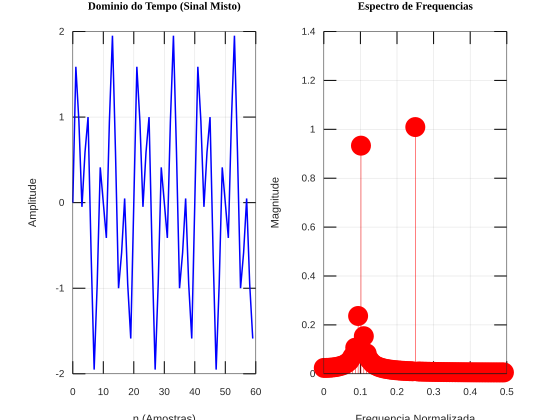

In [4]:
%%octave
clc; clear; close all;

% Parametros do sinal
N = 128;
n = 0:N-1;
f1 = 0.1;  % Frequencia 1
f2 = 0.25; % Frequencia 2

% Sinal composto (soma de duas senoides)
x2 = sin(2*pi*f1*n) + sin(2*pi*f2*n);

% Calculo da FFT
X2 = fft(x2);
X2_mag = abs(X2) / (N/2); % Normalizacao da magnitude
f_eixo = (0:N-1)/N;       % Eixo de frequencias normalizadas

% Plotagem
figure;

subplot(1, 2, 1);
plot(n(1:60), x2(1:60), 'b', 'LineWidth', 1.5);
grid on; title('Dominio do Tempo (Sinal Misto)'); xlabel('n (Amostras)'); ylabel('Amplitude');

subplot(1, 2, 2);
stem(f_eixo(1:N/2), X2_mag(1:N/2), 'filled', 'r');
grid on; title('Espectro de Frequencias'); xlabel('Frequencia Normalizada'); ylabel('Magnitude');

**Discussão (Questão 2):** Observando o sinal resultante no domínio do tempo, a forma de onda se apresenta irregular e complexa. Visualmente, é muito difícil deduzir quais frequências exatas compõem essa mistura. No entanto, ao analisarmos o domínio da frequência, o espectro atua como um "prisma" matemático, isolando perfeitamente as componentes e exibindo dois picos distintos em $f_1 = 0,1$ e $f_2 = 0,25$. Isso evidencia que a Transformada de Fourier é essencial para separar e identificar informações que estão "camufladas" na representação temporal.

## Questão 3: O Fenômeno de Aliasing

**Objetivo:** Considerar um sinal senoidal com frequência elevada e reduzir a taxa de amostragem utilizada em sua geração. Comparar os espectros obtidos antes e depois da redução da taxa de amostragem e explicar o fenômeno de aliasing observado.

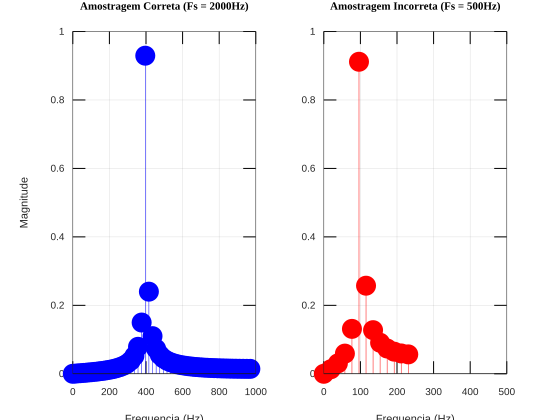

In [5]:
%%octave
clc; clear; close all;

% Simulando um tempo continuo para uma onda de 400 Hz
F_sinal = 400;

% 1. Amostragem Correta (Fs = 2000 Hz, Nyquist respeitado)
Fs_alta = 2000;
t_alta = 0:1/Fs_alta:0.05;
x_alta = sin(2*pi*F_sinal*t_alta);
X_alta = abs(fft(x_alta)) / (length(x_alta)/2);
f_eixo_alta = (0:length(x_alta)-1)*(Fs_alta/length(x_alta));

% 2. Amostragem Incorreta (Fs = 500 Hz, Nyquist violado)
Fs_baixa = 500;
t_baixa = 0:1/Fs_baixa:0.05;
x_baixa = sin(2*pi*F_sinal*t_baixa);
X_baixa = abs(fft(x_baixa)) / (length(x_baixa)/2);
f_eixo_baixa = (0:length(x_baixa)-1)*(Fs_baixa/length(x_baixa));

% Plotagem
figure;

subplot(1, 2, 1);
stem(f_eixo_alta(1:floor(end/2)), X_alta(1:floor(end/2)), 'filled', 'b');
grid on; title('Amostragem Correta (Fs = 2000Hz)'); xlabel('Frequencia (Hz)'); ylabel('Magnitude');
xlim([0 1000]);

subplot(1, 2, 2);
stem(f_eixo_baixa(1:floor(end/2)), X_baixa(1:floor(end/2)), 'filled', 'r');
grid on; title('Amostragem Incorreta (Fs = 500Hz)'); xlabel('Frequencia (Hz)');
xlim([0 500]);

**Discussão (Questão 3):** O Teorema de Nyquist estabelece que a taxa de amostragem ($F_s$) deve ser pelo menos o dobro da maior frequência do sinal ($F_s > 2 \times 400 \rightarrow F_s > 800$ Hz) para evitar perda de informação.
No primeiro gráfico, amostramos a $2000$ Hz (respeitando Nyquist), e o pico apareceu corretamente na frequência real de **$400$ Hz**.
No segundo gráfico, reduzimos a taxa para $500$ Hz (amostragem lenta). Ocorreu o fenômeno do **Aliasing**: o sinal de $400$ Hz não pôde ser representado adequadamente e sua energia rebateu para dentro da banda base, aparecendo falsamente como um pico em **$100$ Hz**. Fisicamente, o sistema passa a "enxergar" uma frequência baixa que não existe no mundo real, o que corromperia a análise de qualquer sistema físico ou biomédico.

## Questão 4: Efeito do Janelamento e Vazamento Espectral

**Objetivo:** Gerar um sinal discreto finito e calcular sua FFT sem aplicação de janela (retangular). Em seguida, aplicar uma janela de Hamming ao mesmo sinal e recalcular o espectro. Comparar os resultados e discutir o efeito do janelamento sobre o vazamento espectral.

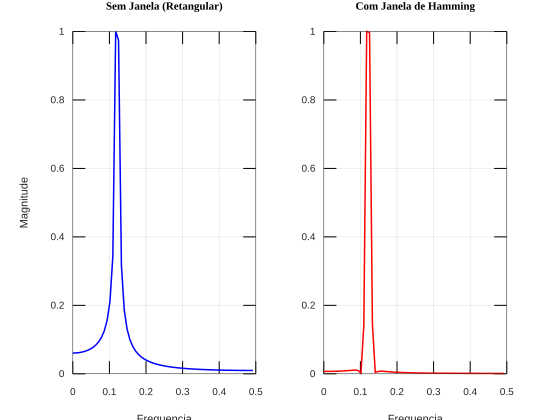

In [6]:
%%octave
clc; clear; close all;

N = 128;
n = 0:N-1;
% Escolhendo uma frequencia que NAO seja multipla exata da resolucao da FFT
% para forcarmos o efeito de vazamento espectral
f0 = 15.5 / 128;
x = sin(2*pi*f0*n);

% 1. FFT sem janela (Janela Retangular implicita)
X_ret = abs(fft(x));
X_ret = X_ret / max(X_ret); % Normalizando

% 2. FFT com Janela de Hamming
janela = hamming(N)';
x_janelado = x .* janela;
X_ham = abs(fft(x_janelado));
X_ham = X_ham / max(X_ham);

f_eixo = (0:N-1)/N;

% Plotagem
figure;

subplot(1, 2, 1);
plot(f_eixo(1:N/2), X_ret(1:N/2), 'b', 'LineWidth', 1.5);
grid on; title('Sem Janela (Retangular)'); xlabel('Frequencia'); ylabel('Magnitude');

subplot(1, 2, 2);
plot(f_eixo(1:N/2), X_ham(1:N/2), 'r', 'LineWidth', 1.5);
grid on; title('Com Janela de Hamming'); xlabel('Frequencia');

**Discussão (Questão 4):** Quando a frequência de um sinal não completa um ciclo exato dentro do bloco de amostras, o corte abrupto nas bordas (inerente à janela retangular) gera altas frequências espúrias. Isso é o **vazamento espectral** (*spectral leakage*), visível no primeiro gráfico como ondas espalhadas na base do pico principal.

Ao aplicarmos a janela de Hamming, o sinal é atenuado suavemente nas bordas, eliminando a descontinuidade abrupta. O resultado no segundo gráfico é a supressão quase total dos lóbulos laterais (o ruído de base some), à custa de um leve alargamento do lóbulo principal. É um *trade-off* clássico em engenharia.

## Questão 5: Análise de Sinais Corrompidos por Ruído

**Objetivo:** Considerar um sinal composto por uma senoide e ruído aditivo. Calcular sua FFT e analisar a dificuldade de identificar a frequência principal no tempo, discutindo como a análise espectral auxilia na separação entre o componente útil e as perturbações.

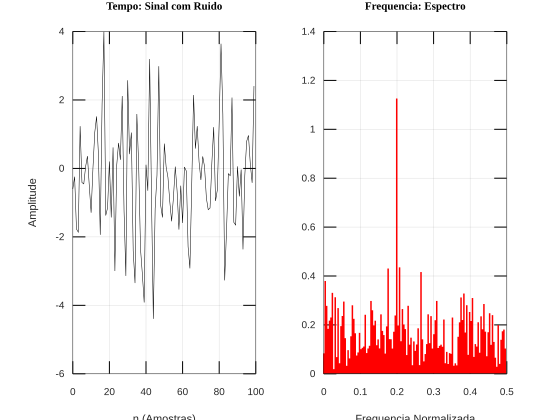

In [7]:
%%octave
clc; clear; close all;

N = 256;
n = 0:N-1;
f_util = 0.2;

% Sinal limpo + Ruido Gaussiano Branco
x_limpo = sin(2*pi*f_util*n);
ruido = 1.5 * randn(1, N); % Ruido com amplitude maior que o sinal
x_corrompido = x_limpo + ruido;

% Calculo da FFT
X_ruido = abs(fft(x_corrompido)) / (N/2);
f_eixo = (0:N-1)/N;

% Plotagem
figure;

subplot(1, 2, 1);
plot(n(1:100), x_corrompido(1:100), 'k');
grid on; title('Tempo: Sinal com Ruido'); xlabel('n (Amostras)'); ylabel('Amplitude');

subplot(1, 2, 2);
stem(f_eixo(1:N/2), X_ruido(1:N/2), 'Marker', 'none', 'LineWidth', 1.5, 'Color', 'r');
grid on; title('Frequencia: Espectro'); xlabel('Frequencia Normalizada');

**Discussão (Questão 5):** No domínio do tempo (gráfico preto), a amplitude aleatória do ruído mascara completamente a senoide original, tornando a análise visual inútil para diagnósticos.

Entretanto, o ruído branco tem uma característica especial: sua energia é distribuída por **todas** as frequências. A energia da senoide útil, por outro lado, está concentrada em uma única frequência. Ao aplicar a FFT (gráfico vermelho), o pico de $f = 0,2$ destaca-se enormemente do "chão" de ruído, provando que o domínio da frequência é a ferramenta ideal para separar e recuperar sinais vitais de ambientes ruidosos.

## Questão 6: Implementação Direta da DFT vs. FFT

**Objetivo:** Implementar a DFT de forma direta, utilizando a definição matemática, para um sinal curto. Comparar o resultado com a função `fft()` nativa e discutir a equivalência matemática e a diferença no custo computacional.

In [8]:
%%octave
clc; clear; close all;

N = 64;
n = 0:N-1;
x = cos(2*pi*0.1*n); % Sinal de teste

% 1. Calculando a DFT pela definicao matematica direta (lacos FOR)
X_dft = zeros(1, N);
for k = 0:N-1
    soma = 0;
    for m = 0:N-1
        soma = soma + x(m+1) * exp(-1j * 2 * pi * k * m / N);
    end
    X_dft(k+1) = soma;
end

% 2. Calculando via algoritmo FFT nativo
X_fft = fft(x);

% Verificando a diferenca maxima absoluta entre os metodos
erro_maximo = max(abs(X_dft - X_fft));

disp('--- Comparacao DFT Direta vs FFT ---');
disp(['Erro maximo entre os metodos: ', num2str(erro_maximo)]);

--- Comparacao DFT Direta vs FFT ---

Erro maximo entre os metodos: 3.8364e-13

**Discussão (Questão 6):** Ao executar o código, o console exibirá um erro máximo extremamente próximo de zero (na casa de $10^{-14}$, devido apenas à precisão de ponto flutuante da máquina). Isso comprova que a FFT **não é um cálculo aproximado**, mas sim a resolução exata da DFT matemática.
A vantagem vital da FFT é algorítmica: enquanto a DFT direta baseada em iterações aninhadas cresce a um custo de $O(N^2)$ — o que travaria um microcontrolador processando áudio longo —, a otimização da FFT reduz o esforço para $O(N \log_2 N)$, viabilizando o Processamento Digital de Sinais em tempo real em hardwares modestos.

## Questão 7: Transformada-Z e Estabilidade Numérica

**Objetivo:** Considerar a função de transferência discreta $H(z) = \frac{1}{1 - 0.8z^{-1}}$. Determinar numericamente sua resposta ao impulso, representá-la graficamente e discutir se o sistema é estável com base no comportamento da sequência.

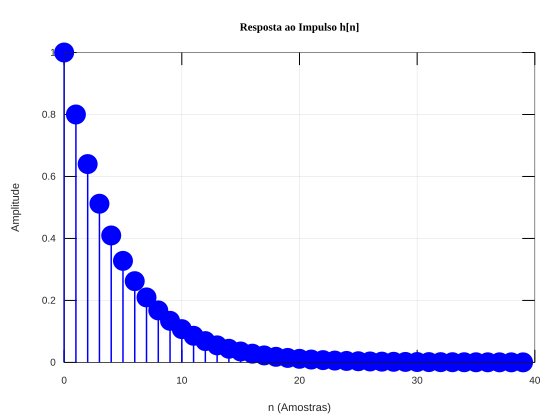

In [9]:
%%octave
clc; clear; close all;

% Coeficientes da equacao de diferencas a partir de H(z)
% Y(z)[1 - 0.8z^-1] = X(z)  =>  y[n] - 0.8y[n-1] = x[n]
b = [1];       % Coeficientes do numerador (entradas)
a = [1, -0.8]; % Coeficientes do denominador (saidas / realimentacao)

% Gerando o impulso discreto (1 na primeira amostra, 0 nas demais)
N_amostras = 40;
impulso = [1, zeros(1, N_amostras-1)];

% Calculando a resposta ao impulso iterativamente usando a funcao filter
h = filter(b, a, impulso);

% Plotagem
figure;
stem(0:N_amostras-1, h, 'filled', 'b', 'LineWidth', 1.5);
grid on; title('Resposta ao Impulso h[n]'); xlabel('n (Amostras)'); ylabel('Amplitude');

**Discussão (Questão 7):** A resposta ao impulso obtida exibe o formato de um decaimento exponencial discreto, dado matematicamente por $h[n] = (0,8)^n u[n]$. Analisando a função de transferência $H(z)$, identificamos que o sistema possui um polo em $z = 0,8$. Como a magnitude deste polo é estritamente menor que 1 ($|0,8| < 1$), ele está localizado dentro do círculo unitário no Plano-Z. Isso garante que a resposta do sistema diminua e tenda a zero com o passar do tempo, confirmando que o sistema é **estável** (BIBO).

## Questão 8: Resolução Espectral e Número de Amostras

**Objetivo:** Considerar dois sinais com durações diferentes (tamanhos de bloco diferentes), mas com a mesma frequência fundamental. Calcular a FFT de ambos, comparar a resolução espectral obtida e explicar a influência do número de amostras na análise em frequência.

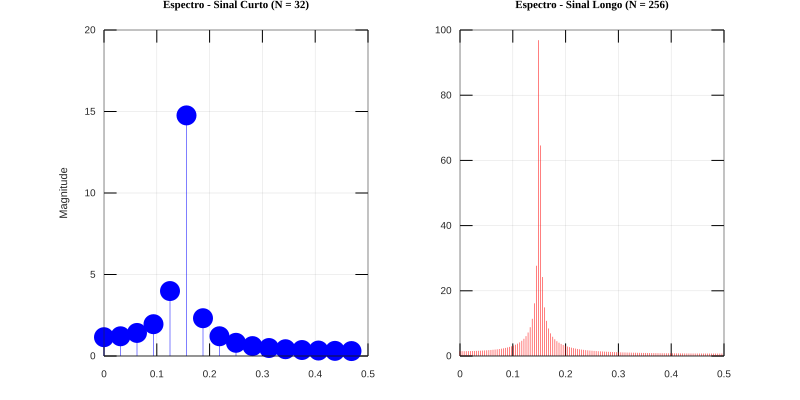

In [10]:
%%octave
clc; clear; close all;

f0 = 0.15; % Frequencia fundamental comum

% Sinal 1: Curto (Poucas amostras)
N1 = 32;
n1 = 0:N1-1;
x1 = sin(2*pi*f0*n1);
X1 = abs(fft(x1));
f_eixo1 = (0:N1-1)/N1;

% Sinal 2: Longo (Muitas amostras)
N2 = 256;
n2 = 0:N2-1;
x2 = sin(2*pi*f0*n2);
X2 = abs(fft(x2));
f_eixo2 = (0:N2-1)/N2;

% Plotagem
figure('Position', [100, 100, 800, 400]);

subplot(1, 2, 1);
stem(f_eixo1(1:N1/2), X1(1:N1/2), 'filled', 'b');
grid on; title('Espectro - Sinal Curto (N = 32)'); xlabel('Frequencia'); ylabel('Magnitude');

subplot(1, 2, 2);
stem(f_eixo2(1:N2/2), X2(1:N2/2), 'filled', 'r', 'Marker', 'none');
grid on; title('Espectro - Sinal Longo (N = 256)'); xlabel('Frequencia');

**Discussão (Questão 8):** O gráfico da esquerda mostra que, com poucas amostras ($N=32$), os "bins" de frequência (as linhas verticais) ficam muito espaçados. A energia do sinal se espalha, criando um pico "largo" e pouco preciso. No gráfico da direita ($N=256$), o aumento do número de amostras no domínio do tempo aumenta drasticamente a **resolução espectral** ($\Delta f = F_s/N$). Com mais bins disponíveis, o pico torna-se extremamente fino e focado exatamente em $f = 0,15$. Na prática, janelas de amostragem mais longas são cruciais para diferenciar frequências que estejam muito próximas umas das outras.

## Questão 9: Componentes Harmônicas e Diagnóstico de Falhas

**Objetivo:** Gerar um sinal contendo uma frequência principal e uma componente harmônica. Calcular o espectro, identificar as frequências e discutir como essa análise é útil no diagnóstico de vibrações mecânicas.

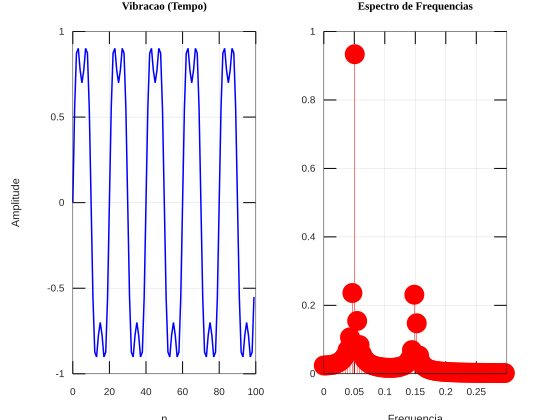

In [11]:
%%octave
clc; clear; close all;

N = 256;
n = 0:N-1;

% Frequencia principal e sua terceira harmonica
f_principal = 0.05;
f_harmonica = 3 * f_principal;

% Sinal: A harmonica geralmente tem amplitude menor que a fundamental
x = 1.0 * sin(2*pi*f_principal*n) + 0.3 * sin(2*pi*f_harmonica*n);

% FFT
X_mag = abs(fft(x)) / (N/2);
f_eixo = (0:N-1)/N;

% Plotagem
figure;

subplot(1, 2, 1);
plot(n(1:100), x(1:100), 'b', 'LineWidth', 1.5);
grid on; title('Vibracao (Tempo)'); xlabel('n'); ylabel('Amplitude');

subplot(1, 2, 2);
stem(f_eixo(1:floor(end/2)), X_mag(1:floor(end/2)), 'filled', 'r');
grid on; title('Espectro de Frequencias'); xlabel('Frequencia');
xlim([0 0.3]);

**Discussão (Questão 9):** O espectro revela claramente a frequência principal ($f = 0,05$) e um pico secundário em seu múltiplo exato ($f = 0,15$, a terceira harmônica). Na engenharia mecânica, essa análise é o pilar da manutenção preditiva. A frequência fundamental costuma representar a rotação normal de um motor (RPM). Se o espectro começar a exibir componentes harmônicas ou sub-harmônicas que não existiam antes, isso assina fisicamente defeitos específicos: desalinhamento de eixos, folga mecânica ou falha nas esferas de um rolamento.

## Questão 10: Análise Prática de Sinal Real (Vibração Simulada)

**Objetivo (Problema Norteador):** Implementar a análise espectral de uma vibração mecânica simulada contendo a dinâmica de um motor, falhas incipientes e ruído de fábrica. Apresentar os gráficos e a interpretação física para resolver o problema norteador do Estudo Dirigido.

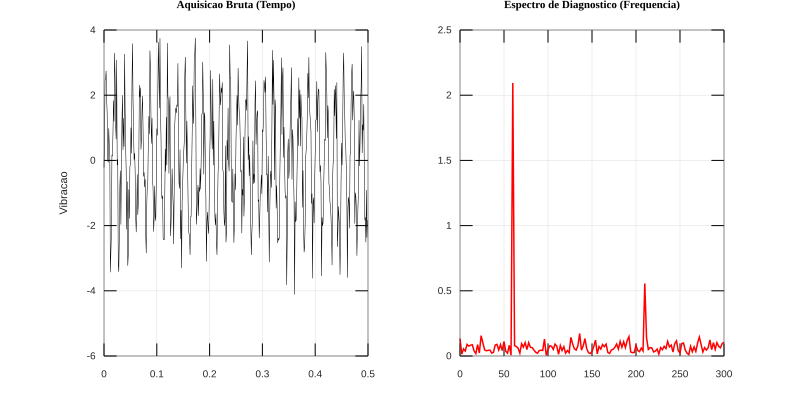

In [12]:
%%octave
clc; clear; close all;

Fs = 1000; % Taxa de amostragem (1 kHz)
t = 0:1/Fs:0.5-1/Fs; % 0.5 segundos de aquisicao
N = length(t);

% Simulando uma maquina rotativa
f_motor = 60;      % Rotacao normal do motor (60 Hz)
f_rolamento = 210; % Frequencia alta gerada por um defeito na pista do rolamento

% Construcao do sinal real: Rotacao + Falha + Ruido de chao de fabrica
x_real = 2.0 * sin(2*pi*f_motor*t) + 0.6 * sin(2*pi*f_rolamento*t) + 0.8 * randn(size(t));

% FFT e correcao do eixo X para Hertz reais
X_real = abs(fft(x_real)) / (N/2);
f_hz = (0:N-1) * (Fs/N);

% Plotagem
figure('Position', [100, 100, 800, 400]);

subplot(1, 2, 1);
plot(t, x_real, 'k');
grid on; title('Aquisicao Bruta (Tempo)'); xlabel('Tempo (s)'); ylabel('Vibracao');

subplot(1, 2, 2);
plot(f_hz(1:N/2), X_real(1:N/2), 'r', 'LineWidth', 1.5);
grid on; title('Espectro de Diagnostico (Frequencia)'); xlabel('Frequencia (Hz)');
xlim([0 300]);

**Discussão (Questão 10 - Resolução do Problema Norteador):** Ao observar a "Aquisição Bruta" no domínio do tempo, vemos apenas um aglomerado caótico de ondas. É humanamente e sistemicamente impossível identificar a saúde da máquina apenas olhando para o histórico temporal.

A aplicação da FFT resolve o **Problema Norteador**. Ao observarmos o Espectro de Diagnóstico, o caos temporal se desfaz, revelando:
1. O pico forte em **60 Hz**, atestando o comportamento dinâmico base do motor.
2. O pico anormal e isolado em **210 Hz**, que funciona como uma "impressão digital" de um desgaste severo no rolamento que estava camuflado pelo ruído.

**Limitações Práticas:** Conforme abordado nas questões anteriores, capturar esses dados no mundo real exige atenção a duas regras fundamentais: garantir uma taxa de amostragem alta o suficiente com o uso de filtros anti-aliasing para evitar distorção de frequência (Nyquist) e colher blocos de dados suficientemente longos (janelamento adequado) para garantir que a resolução do espectro seja fina o bastante para não misturar falhas mecânicas vizinhas.